# A1.1 Aprendizaje estadístico-automático  
## SC3314 – Inteligencia Artificial  
**Universidad de Monterrey**  
**Alumno:** Josué Berdeal  
**Matrícula:** 000635654  
**Profesor:** Dr. Antonio Martínez Torteya  
***Doy mi palbra que he realizado esta actividad con Integridad Academica***

#### Objetivo general del reporte
*Elaborar un reporte técnico que documente el proceso de análisis exploratorio y de inferencia realizado
sobre el conjunto de datos, de tal forma que el lector pueda comprender completamente la metodología,
los resultados y las conclusiones sin necesidad de revisar el código. Toda la interpretación debe
presentarse en texto, tablas y figuras debidamente explicadas.*  


#### Contexto del problema

*En latinoamerica los niveles de obesidad se han convertido en un gran problema en especial en paises como Colombia, Mexico y Peru. Los investigadores de la Universidad de la Costa en Colombia recopilaron los datos con el objetivo de estudiar los distintos tipos de obesidad.*

#### Metodología de análisis

*Se realizó un análisis exploratorio de datos utilizando tablas de contingencia, gráficas de barras y promedios, con el fin de identificar patrones entre el sexo y el nivel de obesidad.* *Se usó un análisis exploratorio porque sirve para ver patrones básicos en los datos. Las tablas y las gráficas ayudan a comparar los niveles de obesidad entre hombres y mujeres. Los promedios permiten ver diferencias generales de peso y edad. Este análisis solo muestra tendencias y no permite decir causas, lo cual es una limitación del estudio.*

*Antes de realizar el análisis, se preparó el entorno de trabajo instalando y cargando las librerías necesarias para la manipulación de datos y la visualización gráfica. Estas herramientas permiten realizar el análisis exploratorio de forma eficiente y reproducible.*

#### Paso 1: Instalar las librerias y funciones para leer archivos, calcular valores y crear graficas


In [15]:
#importamos las libreriras
import pandas as pd #leer archivos
import numpy as np #Calcular valores numericos
import matplotlib.pyplot as plt #crear graficas
#se vea la grafica bonita
%matplotlib inline 

La inspección inicial del conjunto de datos permitió confirmar la correcta lectura del archivo y comprender la naturaleza de las variables, lo cual es fundamental antes de cualquier análisis estadístico.

#### Paso 2: Leer el archivo csv A1.1 Obesidad.csv e imprimir para verificar que contenido hay en las tablas
*El conjunto de datos incluye variables demográficas, de hábitos y de salud, así como una variable
categórica que describe el nivel de obesidad de cada individuo, calculado a partir del índice de masa
corporal.*

In [14]:
data = pd.read_csv("A1.1 Obesidad (1).csv") #Leer el archivo csv
print(data.head())#ver las primeros 5 registros de datos

     Sexo  Edad  Estatura  Peso FamiliarConSobrepeso ComeMuchasCalorias  \
0  Female  21.0      1.62  64.0                  yes                 no   
1  Female  21.0      1.52  56.0                  yes                 no   
2    Male  23.0      1.80  77.0                  yes                 no   
3    Male  27.0      1.80  87.0                   no                 no   
4    Male  22.0      1.78  89.8                   no                 no   

   ComeVegetales Fumador  ConsumoDeAgua      NivelDeObesidad  
0            2.0      no            2.0        Normal_Weight  
1            3.0     yes            3.0        Normal_Weight  
2            2.0      no            2.0        Normal_Weight  
3            3.0      no            2.0   Overweight_Level_I  
4            2.0      no            2.0  Overweight_Level_II  


En la tabla se muestran las primeras cinco observaciones del conjunto de datos, lo que permite identificar su estructura general.

Las variables **Edad**, **Estatura** y **Peso** son **cuantitativas**, ya que representan medidas numéricas.

También se incluyen variables **cualitativas**. Entre las demográficas se encuentra **Sexo**, que clasifica a los individuos como **Female** o **Male**. Otras variables como **FamiliarConSobrepeso**, **ComeMuchasCalorias** y **Fumador** describen hábitos y antecedentes.

Aunque **ComeVegetales** y **ConsumoDeAgua** utilizan valores numéricos, estos representan **niveles de frecuencia** y no cantidades exactas.

Finalmente, **NivelDeObesidad** clasifica a cada persona según su condición corporal.

## Reflexión sobre el diseño del estudio

Se podrían agregar dos variables adicionales: **el nivel de actividad física y las horas de sueño diarias.** La actividad física influye directamente en el gasto energético, por lo que niveles bajos pueden aumentar el riesgo de sobrepeso. Por otro lado, dormir pocas horas puede alterar el metabolismo y favorecer el aumento de peso.


## Variable de interés para inferencia

La variable de salida seleccionada es **NivelDeObesidad**, ya que representa el objetivo principal del estudio al clasificar la condición corporal de los individuos.Ademas, Se eligió el sexo como variable explicativa inicial debido a que es un factor comúnmente asociado a diferencias metabólicas y de hábitos. 



In [17]:
tabla = pd.crosstab(data["NivelDeObesidad"], data["Sexo"]) # se crea una tabla de conteo para ver cuantas mujeres y cuantos hombres hay en cada nivel
tabla

Sexo,Female,Male
NivelDeObesidad,,
Insufficient_Weight,173,99
Normal_Weight,141,146
Obesity_Type_I,156,195
Obesity_Type_II,2,295
Obesity_Type_III,323,1
Overweight_Level_I,145,145
Overweight_Level_II,103,187


Aquí se muestra una tabla resumida por **niveles de obesidad**, donde se observa que hay una mayor cantidad de **hombres** en el **nivel de peso normal**. Asimismo, en el **nivel tres de obesidad** también se presenta una mayor frecuencia de **hombres** en comparación con **mujeres**. Esto sugiere que la **distribución del nivel de obesidad no es igual entre ambos sexos** y que el **sexo puede estar relacionado con diferencias en la condición de peso**.


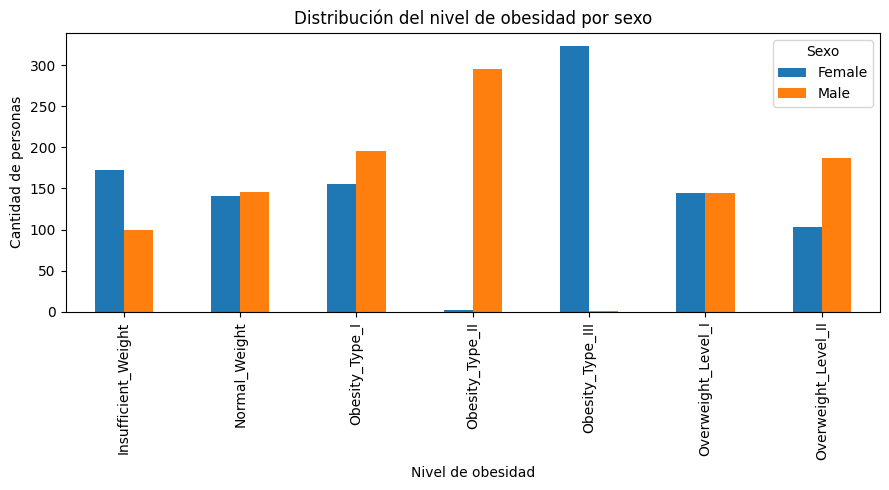

In [34]:
tabla.plot(kind="bar", figsize=(9,5)) # crear una grafica de barras con un ancho y alto (an,al)
plt.xlabel("Nivel de obesidad") #Nombre en eje x
plt.ylabel("Cantidad de personas") #Nombre en eje y
plt.title("Distribución del nivel de obesidad por sexo") #Titulo de la Tabla
plt.tight_layout()
plt.show() # Muestra la grafica

## Análisis de la gráfica de barras

En la gráfica se muestra cómo se distribuyen los niveles de obesidad entre hombres y mujeres. Se observa que en algunos niveles hay más **hombres**, sobre todo en los niveles de **sobrepeso** y **obesidad**, mientras que en el **peso normal** hay una mayor presencia de **mujeres**.

En general, la gráfica muestra que la distribución del nivel de obesidad es diferente entre hombres y mujeres, lo que indica que el sexo puede estar relacionado con la condición de peso.


In [31]:
data.groupby("Sexo")[["Edad", "Peso"]].mean() # Agrupa los datos por sexo y calcula el promedio de edad y peso

,Edad,Peso
Sexo,,
Female,24.001907,82.302364
Male,24.616020,90.769478


## Análisis de promedios por sexo

Al comparar los promedios por sexo, se puede ver que las **mujeres** tienen una edad promedio cercana a los **24 años** y un peso promedio de aproximadamente **82 kg**. En el caso de los **hombres**, la edad promedio es muy similar, alrededor de los **25 años**, pero el peso promedio es mayor, cercano a los **91 kg**.

Esto muestra que, aunque ambos grupos tienen edades parecidas, los hombres tienden a presentar un peso promedio más alto. En general, el menor peso promedio observado en las mujeres sugiere condiciones más favorables en términos de peso dentro del conjunto de datos.


## Conclusión general

*Los resultados muestran diferencias en el nivel de obesidad entre hombres y mujeres aunque la edad promedio es similar. Esto indica que el sexo puede estar relacionado con la condición de peso. El análisis es exploratorio y no permite establecer causas. En futuros estudios se pueden analizar más variables como actividad física y horas de sueño.*